## Import

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from google.colab.patches import cv2_imshow
from sklearn.cluster import KMeans
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
import os
from google.colab import drive

drive.mount("/content/drive", force_remount=True)
data_path = "/content/drive/My Drive/DIP_project"

Mounted at /content/drive


## Functions

### Merging

In [3]:
def get_gt_from_txt(gt_file_name):

  # 0 scene
  # 1 dissolve transition
  # 2 hard cut

  with open(gt_file_name) as f:
    array = [[int(x) for x in line.split()] for line in f]
  f.close()
  intervals=np.asarray(array)

  gt=np.ones((intervals[-1,1]+1), dtype=int)
  for i in range(intervals.shape[0]):
    for j in range(intervals[i,0],intervals[i,1]+1):
      gt[j]=0
    if i!=0 and intervals[i-1,1]==intervals[i,0]-1:
      gt[intervals[i-1,1]]=2

  if gt[0]==1:
    gt=gt[1:]

  return gt

In [4]:
def merge_data_and_gt(idx, errors, gt):
  x=np.zeros((errors.shape), dtype=float)
  y=np.zeros((errors.shape[0]), dtype=float)
  for i in range(errors.shape[0]):
    if idx[i]< gt.shape[0]:
      x[i]=errors[i]
      y[i]=gt[idx[i]]

  return np.squeeze(x),y

In [5]:
def merge_data_and_gt_more_frames(idx, errors, gt, BUFF_LEN):

  errors_buff = np.zeros((errors.shape[0]- BUFF_LEN, errors.shape[1]*BUFF_LEN))
  idx_buff = np.zeros((errors_buff.shape[0]), dtype = int)

  for i in range(idx_buff.shape[0]):
    errors_buff[i] = np.squeeze(np.concatenate(errors[i: i+BUFF_LEN]))
    idx_buff[i] = idx[i+BUFF_LEN//2]

  x,y = merge_data_and_gt(idx_buff, errors_buff, gt)
  print(x.shape)
  print(y.shape)

  return x,y


### Visualization

In [6]:
def count_frames_in_video(video_path):
    # Open the video file
    video = cv2.VideoCapture(video_path)

    # Check if video opened successfully
    if not video.isOpened():
        print(f"Error: Could not open video file {video_path}")
        return None

    # Get the total number of frames in the video
    total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))

    # Release the video file
    video.release()

    return total_frames

In [7]:
def plot_colored_data(x, y, title):
    # Separate the data points based on the labels in y
    x_class_0 = x[y == 0]
    x_class_1 = x[y == 1]
    x_class_2 = x[y == 2]

    # Plot the points with different colors based on their class
    plt.scatter(x_class_0[:, 0], x_class_0[:, 1], color='blue', label='Shot', s=2.5)
    plt.scatter(x_class_1[:, 0], x_class_1[:, 1], color='red', label='Gradual transition', s=15)
    plt.scatter(x_class_2[:, 0], x_class_2[:, 1], color='green', label='Abrupt transition', s=15)

    # Set the labels and title
    plt.title(title)
    plt.legend()
    plt.show()

In [8]:
def visualize_frames(path, start, end):
    cap = cv2.VideoCapture(path)

    if not cap.isOpened():
        print("Error opening video file")
        return

    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    start = max(0, start)
    end = min(frame_count - 1, end)

    cap.set(cv2.CAP_PROP_POS_FRAMES, start)

    for frame_num in range(start, end + 1):
        ret, frame = cap.read()

        if not ret:
            break

        cv2_imshow(frame)



    cap.release()


In [9]:
# Concatenate frames into a single image
def visualize_frames_sequence(video_path, start_frame, end_frame, mode='horizontal'):

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Cannot open video file: {video_path}")

    frames = []
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    # Validate frame range
    if start_frame < 0 or end_frame >= frame_count or start_frame > end_frame:
        cap.release()
        raise ValueError(f"Invalid frame range: {start_frame} to {end_frame}. Total frames: {frame_count}")

    # Read frames within the specified range
    cap.set(cv2.CAP_PROP_POS_FRAMES, start_frame)
    for frame_idx in range(start_frame, end_frame + 1):
        ret, frame = cap.read()
        if not ret:
            break
        # Optionally resize frames for consistency
        frame = cv2.resize(frame, (200, 200))
        frames.append(frame)

    cap.release()

    if not frames:
        raise ValueError("No frames were read from the specified range.")

    # Concatenate frames
    if mode == 'horizontal':
        concatenated_image = np.hstack(frames)
    elif mode == 'vertical':
        concatenated_image = np.vstack(frames)
    else:
        raise ValueError("Mode must be 'horizontal' or 'vertical'.")

    # Convert BGR to RGB for displaying with matplotlib
    concatenated_image_rgb = cv2.cvtColor(concatenated_image, cv2.COLOR_BGR2RGB)

    # Display the concatenated image
    plt.figure(figsize=(20, 10) if mode == 'horizontal' else (10, 20))
    plt.imshow(concatenated_image_rgb)
    plt.axis('off')
    plt.show()

## BBC dataset

### Visualization

In [ ]:
# BBC 1

video_path1 = data_path + "/bbc_dataset/bbc_01.mp4"
gt1 = get_gt_from_txt(data_path+"/bbc_gt/01.txt")
idx1 = np.load(data_path+"/bbc_idx/bbc_01_idx.npy")
errors1 = np.load(data_path+"/bbc_errors/bbc_01_errors.npy")

In [ ]:
number_of_frames = count_frames_in_video(video_path1)
print(errors1.shape)
print("Total video frame: ",number_of_frames)
print("Number of buffers: ",idx1.shape[0])
print("Number of labels: ",gt1.shape[0])
print("Number of 0 labels: ",np.sum(gt1 == 0))
print("Number of 1 labels: ",np.sum(gt1 == 1))
print("Hard cut idx: ",np.where( gt1==2)[0])

(73844, 135, 1)
Total video frame:  73875
Number of buffers:  73844
Number of labels:  73855
Number of 0 labels:  72531
Number of 1 labels:  891
Hard cut idx:  [  770   891  1301  1568  1818  2110  2895  3028  3156  3421  3570  3701
  3819  3922  4099  4271  4387  4544  4672  4870  5081  5229  5460  5599
  5799  5924  5999  6326  6480  6588  6747  6858  6975  7107  7262  7403
  7559  7768  7907  8386  8540  8743  8893  9027  9379  9813 10044 10313
 10779 10910 11077 11202 11322 11518 11645 11926 12123 12333 12521 12718
 13482 13938 14082 14276 14605 14732 14901 15101 15245 15365 15580 15802
 15940 16073 16218 16348 16473 16531 16606 16686 16765 16837 16920 17062
 17127 17228 17286 17650 17775 18011 18093 18383 18451 19325 20012 20422
 20566 20735 20909 21087 21366 21711 22304 22671 22811 22959 23088 23200
 23294 23358 23463 23511 23582 23632 23885 24273 24447 24542 24669 24713
 24856 25069 25423 25489 25602 25779 25830 25858 26177 26248 26538 26680
 26938 27301 27554 27688 27925 28013 

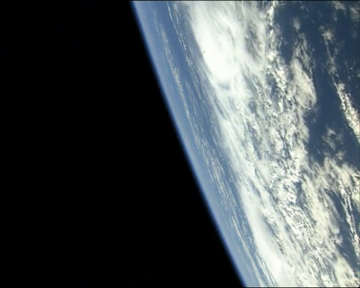

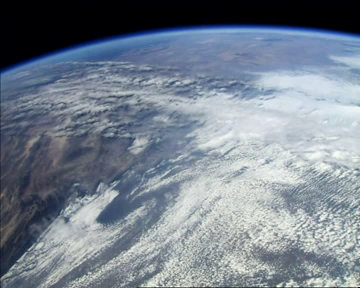

In [ ]:
# Visualize hc frames

start = 891
end = 892
visualize_frames(video_path1, start, end)

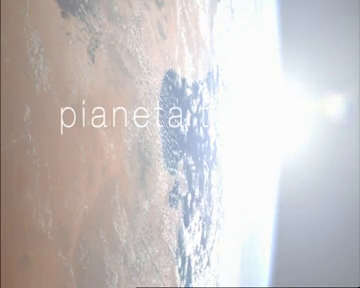

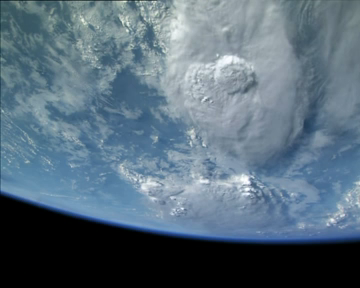

In [ ]:
# Visualize dissolve

start = 649
end = 650
visualize_frames(video_path1, start, end)

In [ ]:
gt1[649] = 2
gt1[632:649] = 1

(73844, 135)
Number of labels:  73844
Number of 0 labels:  72519
Number of 1 labels:  891
Hard cut idx:  434


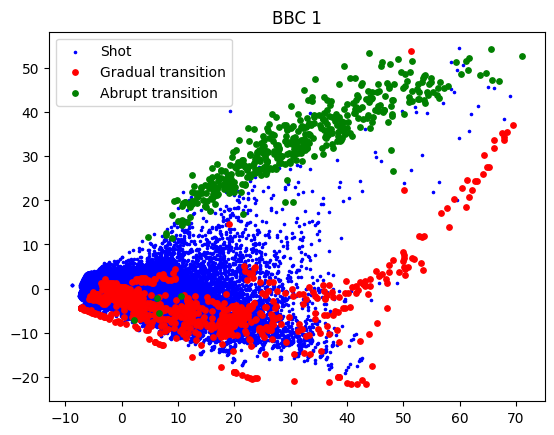

In [ ]:
# PCA 2D

x_1,y_1=merge_data_and_gt(idx1, errors1, gt1)
print(x_1.shape)
print("Number of labels: ",y_1.shape[0])
print("Number of 0 labels: ",np.sum(y_1 == 0))
print("Number of 1 labels: ",np.sum(y_1 == 1))
print("Hard cut idx: ",np.sum( y_1==2))

np.save(data_path+"/bbc_01_x.npy",x_1)
np.save(data_path+"/bbc_01_y.npy", y_1)

scaler = StandardScaler()
normalized_x_1 = scaler.fit_transform(x_1)
pca = PCA(n_components=2)  # Reduce to 2 principal components
principal_components = pca.fit_transform(normalized_x_1)

plot_colored_data(principal_components, y_1, "BBC 1")

(73833, 1485)
(73833,)
(73833, 1485)
Number of labels:  (73833,)
Number of 0 labels:  72508
Number of 1 labels:  891
Hard cut idx:  434


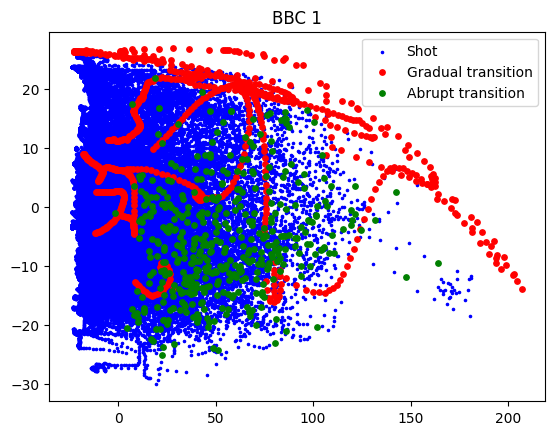

In [ ]:
BUFF_LEN = 11
x_buff_1, y_buff_1 = merge_data_and_gt_more_frames(idx1, errors1, gt1, BUFF_LEN)
print(x_buff_1.shape)
print("Number of labels: ",y_buff_1.shape)
print("Number of 0 labels: ",np.sum(y_buff_1 == 0))
print("Number of 1 labels: ",np.sum(y_buff_1 == 1))
print("Hard cut idx: ",np.sum( y_buff_1==2))

# PCA 2D
scaler = StandardScaler()
normalized_x_buff_1 = scaler.fit_transform(x_buff_1)
pca = PCA(n_components=2)  # Reduce to 2 principal components
principal_components = pca.fit_transform(normalized_x_buff_1)

plot_colored_data(principal_components, y_buff_1, "BBC 1")

### Vector extraction

In [ ]:
for i in range(1,12):
  if i < 10:
    idx = np.load(data_path+"/bbc_idx/bbc_0" + str(i) +"_idx.npy")
    errors = np.load(data_path+"/bbc_errors/bbc_0" + str(i) +"_errors.npy")
    gt = get_gt_from_txt(data_path+"/bbc_gt/0" + str(i) +".txt")
  else:
    idx = np.load(data_path+"/bbc_idx/bbc_" + str(i) +"_idx.npy")
    errors = np.load(data_path+"/bbc_errors/bbc_" + str(i) +"_errors.npy")
    gt = get_gt_from_txt(data_path+"/bbc_gt/" + str(i) +".txt")

  x,y=merge_data_and_gt(idx, errors, gt)
  np.save(data_path+"/bbc_vec/bbc_0" + str(i) +"_x.npy",x)
  np.save(data_path+"/bbc_vec/bbc_0" + str(i) +"_y.npy", y)


In [ ]:
BUFF_LEN = 11
for i in range(10,12):
  if i < 10:
    idx = np.load(data_path+"/bbc_idx/bbc_0" + str(i) +"_idx.npy")
    errors = np.load(data_path+"/bbc_errors/bbc_0" + str(i) +"_errors.npy")
    gt = get_gt_from_txt(data_path+"/bbc_gt/0" + str(i) +".txt")
  else:
    idx = np.load(data_path+"/bbc_idx/bbc_" + str(i) +"_idx.npy")
    errors = np.load(data_path+"/bbc_errors/bbc_" + str(i) +"_errors.npy")
    gt = get_gt_from_txt(data_path+"/bbc_gt/" + str(i) +".txt")

  x,y=merge_data_and_gt_more_frames(idx, errors, gt, BUFF_LEN)

  np.save(data_path+"/bbc_vec_buff/bbc_0" + str(i) +"_x.npy",x)
  np.save(data_path+"/bbc_vec_buff/bbc_0" + str(i) +"_y.npy", y)
  print("saving vectors for bbc_0" + str(i) +".npy")


(73833, 1485)
(73833,)
saving vectors for bbc_010.npy
(73450, 1485)
(73450,)
saving vectors for bbc_011.npy


### Preprocessing

## SVC classification

In [ ]:
# SVC classification

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(x_1,y_1, test_size=0.3, random_state=42)

# Create parameters to test
param_grid = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto']
}


svc = SVC()
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, scoring='accuracy', verbose=0)
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

: 

In [ ]:
# SVC classification

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(x_1,y_1, test_size=0.3, random_state=42)

# Create an SVM model with a linear kernel
svm_model = SVC(kernel='rbf', C = 10, gamma = 'scale')

# Train the model
svm_model.fit(X_train, y_train)

# Predict the labels of the test set
y_pred = svm_model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Shot", " Gradual", "Abrupt"])

# Plot confusion matrix
disp.plot(cmap=plt.cm.Blues, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 99.87%


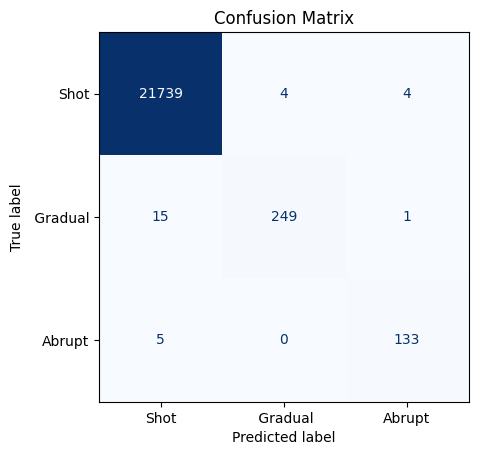

Confusion Matrix:
[[21739     4     4]
 [   15   249     1]
 [    5     0   133]]


In [ ]:
# SVC classification

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(x_buff_1,y_buff_1, test_size=0.3, random_state=42)

# Create an SVM model with a linear kernel
svm_model = SVC(kernel='rbf', C = 10, gamma = 'scale')

# Train the model
svm_model.fit(X_train, y_train)

# Predict the labels of the test set
y_pred = svm_model.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Shot", " Gradual", "Abrupt"])

# Plot confusion matrix
disp.plot(cmap=plt.cm.Blues, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

print("Confusion Matrix:")
print(conf_matrix)

In [ ]:
# BBC 3

video_path3 = data_path + "/bbc_03.mp4"
gt3 = get_gt_from_txt(data_path+"/03_Ice Worlds.txt")
idx3 = np.load(data_path+"/bbc_03_idx.npy")
errors3 = np.load(data_path+"/bbc_03_errors.npy")
number_of_frames = count_frames_in_video(video_path3)
print("Total video frame: ",number_of_frames)
print("Number of buffers: ",idx3.shape[0])
print("Number of labels: ",gt3.shape[0])
print("Number of 0 labels: ",np.sum(gt3 == 0))
print("Number of 1 labels: ",np.sum(gt3 == 1))
print("Hard cut idx: ",np.where( gt3==2)[0])

Total video frame:  73925
Number of buffers:  73894
Number of labels:  73925
Number of 0 labels:  72889
Number of 1 labels:  626
Hard cut idx:  [ 2111  2394  2741  2913  3206  3448  3697  3952  4038  4105  4212  4275
  4355  4520  4679  4759  4841  4935  5047  5291  5575  5740  5840  6073
  6174  6255  6292  6399  6556  6693  6851  7212  7412  7653  7804  7936
  8080  8205  8368  8481  8571  8726  8771  8844  8908  9036  9226  9384
  9551  9709  9863  9918 10012 10298 10333 10445 10514 10668 10946 11055
 11434 11603 11904 12422 12611 12772 12979 13219 13380 13485 13796 13877
 14054 14176 14281 14361 14524 14659 14743 14815 14860 15218 15295 15425
 15653 15845 15983 16162 16413 16762 16871 16970 17073 17254 17379 17542
 17696 17883 18043 18397 18525 18604 18684 18844 18922 18984 19062 19131
 19264 19458 19639 19906 20044 20256 20342 20732 20814 20929 21069 21237
 21432 21615 21771 21887 22007 22103 22207 22378 22498 22590 22687 22803
 22901 23144 23215 23295 23427 23609 23721 23796 2387

In [ ]:
start = 2394
end = 2395
visualize_frames(video_path3, start, end)

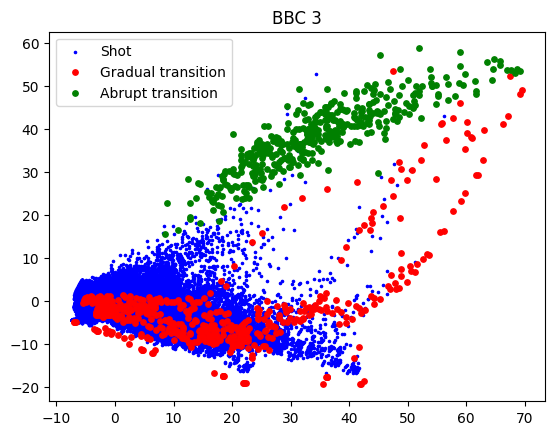

In [ ]:
# PCA 2D

x_3,y_3=merge_data_and_gt(idx3, errors3, gt3)
np.save(data_path+"/bbc_03_x.npy",x_3)
np.save(data_path+"/bbc_03_y.npy", y_3)

scaler = StandardScaler()
normalized_x_3 = scaler.fit_transform(x_3)
pca = PCA(n_components=2)  # Reduce to 2 principal components
principal_components = pca.fit_transform(normalized_x_3)

plot_colored_data(principal_components, y_3, "BBC 3")

In [ ]:
x_buff_3, y_buff_3 = merge_data_and_gt_more_frames(idx3, errors3, gt3, BUFF_LEN)

In [ ]:
# SVC classification

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(x_3,y_3, test_size=0.3, random_state=42)

# Create parameters to test
param_grid = {
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto']
}


svc = SVC()
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, scoring='accuracy', verbose=0)
grid_search.fit(X_train, y_train)

print("Best parameters found: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

Best parameters found:  {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Best score:  0.9989753504108265


Accuracy: 99.84%


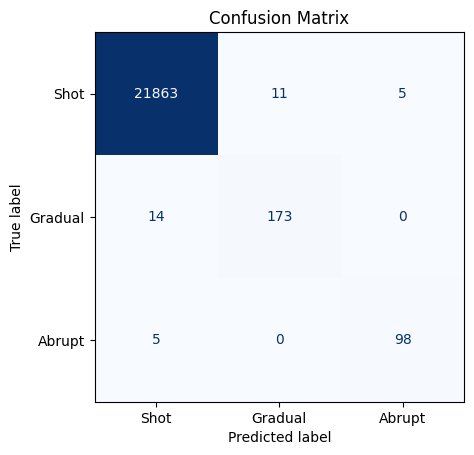

Confusion Matrix:
[[21863    11     5]
 [   14   173     0]
 [    5     0    98]]
Confusion Matrix:
[[21863    11     5]
 [   14   173     0]
 [    5     0    98]]


In [ ]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(x_3,y_3, test_size=0.3, random_state=42)

svc = SVC(kernel='rbf', C = 10, gamma = 'scale')

# Train the model
svc.fit(X_train, y_train)

# Predict the labels of the test set
y_pred = svc.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Shot", "Gradual", "Abrupt"])

# Plot confusion matrix
disp.plot(cmap=plt.cm.Blues, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

print("Confusion Matrix:")
print(conf_matrix)
print("Confusion Matrix:")
print(conf_matrix)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x_buff_3,y_buff_3, test_size=0.3, random_state=42)

svc = SVC(kernel='rbf', C = 100, gamma = 'scale')

# Train the model
svc.fit(X_train, y_train)

# Predict the labels of the test set
y_pred = svc.predict(X_test)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 99.93%
Confusion Matrix:
[[21852     0     2]
 [   12   182     0]
 [    2     0   116]]


In [ ]:
# Predict the labels of the test set
y_pred = svc.predict(x_buff_1)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_buff_1, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_buff_1, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 98.86%
Confusion Matrix:
[[72392   125     9]
 [  688   186     0]
 [   16     1   417]]


In [ ]:
# BBC 2

video_path2 = data_path + "/bbc_02.mp4"
gt2 = get_gt_from_txt(data_path+"/02_Mountains.txt")
idx2 = np.load(data_path+"/bbc_02_idx.npy")
errors2 = np.load(data_path+"/bbc_02_errors.npy")

In [ ]:
number_of_frames = count_frames_in_video(video_path2)
print("Total video frame: ",number_of_frames)
print("Number of buffers: ",idx2.shape[0])
print("Number of labels: ",gt2.shape[0])
print("Number of 0 labels: ",np.sum(gt2 == 0))
print("Number of 1 labels: ",np.sum(gt2 == 1))
print("Hard cut idx: ",np.where( gt2==2)[0])

Total video frame:  72115
Number of buffers:  72084
Number of labels:  72095
Number of 0 labels:  70437
Number of 1 labels:  1294
Hard cut idx:  [  649  2324  2647  2845  2965  3067  3192  3302  3406  3509  3607  3855
  4074  4202  4651  4800  5013  5402  5511  5608  5712  5910  6005  6108
  6216  6335  6444  6519  6620  6714  6772  6838  6896  6953  7060  7124
  7210  7277  7338  7393  7464  7522  7557  7609  7695  7816  7882  7956
  8035  8122  8172  8224  8268  8341  8417  8546  8762  8948  9102  9235
  9316  9507  9619  9716  9824 10132 10200 10448 10540 10710 10765 10829
 10903 10956 11038 11076 11141 11158 11234 11262 11322 11392 11454 11531
 11633 11718 11832 11956 12148 12511 12736 12916 13100 13517 13643 13820
 13917 14014 14126 14243 14341 14446 14550 14666 14790 14922 15034 15354
 15566 15766 15955 16047 16274 16415 16615 16950 17064 17171 17281 17432
 17561 17672 17804 18008 18129 18155 18174 18195 18214 18258 18419 18592
 18675 18774 18942 19073 19189 19325 19485 19632 197

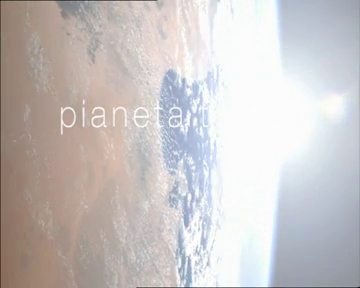

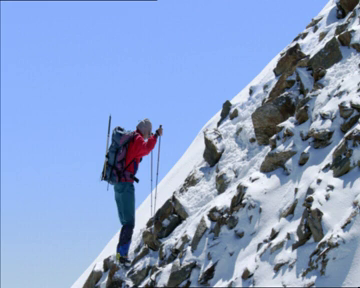

In [ ]:
# Visualize frame

start = 649
end = 650
visualize_frames(video_path2, start, end)


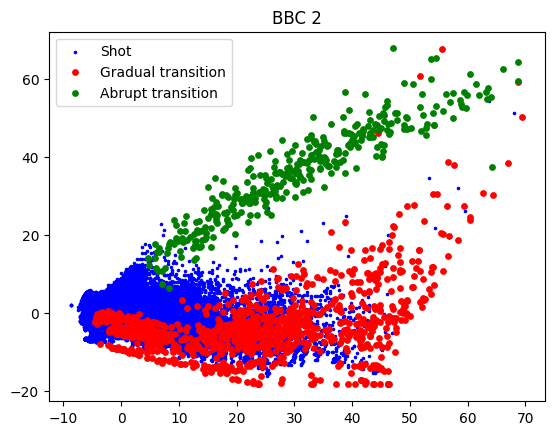

In [ ]:
# 2D PCA

x_2,y_2=merge_data_and_gt(idx2, errors2, gt2)
np.save(data_path+"/bbc_02_x.npy",x_2)
np.save(data_path+"/bbc_02_y.npy", y_2)

scaler = StandardScaler()
pca = PCA(n_components=2)  # Reduce to 2 principal components
normalized_x_2 = scaler.fit_transform(x_2)
principal_components = pca.fit_transform(normalized_x_2)

plot_colored_data(principal_components, y_2, "BBC 2")

In [ ]:
x_buff_2, y_buff_2 = merge_data_and_gt_more_frames(idx2, errors2, gt2, BUFF_LEN)

In [ ]:
# BBC 4
video_path4 = data_path + "/bbc_04.mp4"
gt4 = get_gt_from_txt(data_path+"/04_Great Plains.txt")
idx4 = np.load(data_path+"/bbc_04_idx.npy")
errors4 = np.load(data_path+"/bbc_04_errors.npy")

x_4,y_4=merge_data_and_gt(idx4, errors4, gt4)
np.save(data_path+"/bbc_04_x.npy",x_4)
np.save(data_path+"/bbc_04_y.npy", y_4)

# BBC 5
video_path5 = data_path + "/bbc_05.mp4"
gt5 = get_gt_from_txt(data_path+"/05_Jungles.txt")
idx5 = np.load(data_path+"/bbc_05_idx.npy")
errors5 = np.load(data_path+"/bbc_05_errors.npy")

x_5,y_5=merge_data_and_gt(idx5, errors5, gt5)
np.save(data_path+"/bbc_05_x.npy",x_5)
np.save(data_path+"/bbc_05_y.npy", y_5)

# BBC 6
video_path6 = data_path + "/bbc_06.mp4"
gt6 = get_gt_from_txt(data_path+"/06_Seasonal_Forests.txt")
idx6 = np.load(data_path+"/bbc_06_idx.npy")
errors6 = np.load(data_path+"/bbc_06_errors.npy")

x_6,y_6=merge_data_and_gt(idx6, errors6, gt6)
np.save(data_path+"/bbc_06_x.npy",x_6)
np.save(data_path+"/bbc_06_y.npy", y_6)

In [ ]:
# Train set is composed of shots taken from different videos

x_class_2 = np.concatenate((x_1[y_1 == 2], x_3[y_3 == 2], x_2[y_2==2], x_4[y_4 == 2], x_5[y_5==2], x_6[y_6==2]))

x_class_0 = np.concatenate((x_1[y_1 == 0], x_3[y_3 == 0], x_2[y_2==0], x_4[y_4==0], x_5[y_5==0], x_6[y_6==0]))

x_class_1 = np.concatenate((x_1[y_1 == 1], x_3[y_3==1], x_2[y_2==1], x_4[y_4==1], x_5[y_5==1], x_6[y_6==1]))

size_class_2 = 2645
size_class_0 = 2645
size_class_1 = 2645


x_class_0_idx = np.random.choice(x_class_0.shape[0], size=size_class_0, replace=False)
x_class_0 = x_class_0[x_class_0_idx,:]

x_class_1_idx = np.random.choice(x_class_1.shape[0], size=size_class_1, replace=False)
x_class_1 = x_class_1[x_class_1_idx,:]

x_class_2_idx = np.random.choice(x_class_2.shape[0], size=size_class_2, replace=False)
x_class_2 = x_class_2[x_class_2_idx,:]

X_train = np.concatenate((x_class_2, x_class_0, x_class_1))
y_train = np.concatenate((np.ones(size_class_2)*2, np.zeros(size_class_0), np.ones(size_class_1)))

In [ ]:
print(y_train.shape)

(7935,)


Accuracy: 93.88%


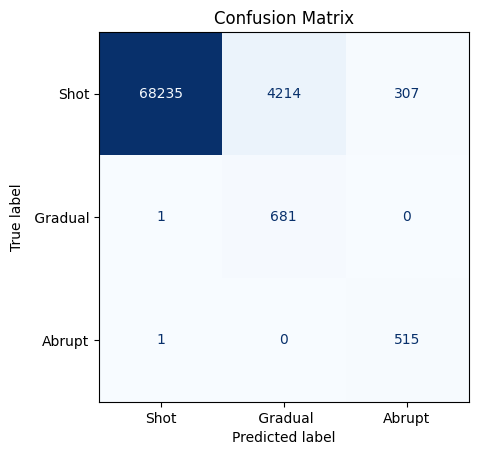

In [ ]:
svc = SVC(kernel='rbf', C = 10, gamma = 'scale')

# Train the model
svc.fit(X_train, y_train)

# Predict the labels of the test set
y_pred = svc.predict(x_6)

# Calculate the accuracy of the model
accuracy = accuracy_score(y_6, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# Generate the confusion matrix
conf_matrix = confusion_matrix(y_6, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=["Shot", " Gradual", "Abrupt"])

# Plot confusion matrix
disp.plot(cmap=plt.cm.Blues, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

## BERT

In [ ]:
# Install the Hugging Face transformers library
!pip install transformers

In [ ]:
import torch
from torch.utils.data import TensorDataset, DataLoader # Import TensorDataset and DataLoader
from torch import nn
!pip install torchinfo
from torchinfo import summary

In [ ]:
# Construct tensors
x_tensor = torch.tensor(x_1, dtype=torch.float32)
x_tensor = x_tensor.unsqueeze(1) # Reshape features to [batch_size, sequence_length, input_dim]
y_tensor = torch.tensor(y_1, dtype=torch.long)
print(x_tensor.shape)
print(y_tensor.shape)

# Create train-test split
#x_train, x_val, y_train, y_val = train_test_split(x_tensor, y_tensor, test_size=0.3, random_state=42)

In [ ]:
from transformers import AutoModel, AutoConfig

# Replace the input and output layers
class FeatureClassifier(nn.Module):
    def __init__(self, base_model, feature_dim, num_labels):
        super(FeatureClassifier, self).__init__()
        self.feature_embed = nn.Linear(feature_dim, base_model.config.hidden_size)
        self.transformer = base_model
        self.classifier = nn.Linear(base_model.config.hidden_size, num_labels)

    def forward(self, x):
        x_emb = self.feature_embed(x)
        transformer_out = self.transformer(inputs_embeds=x_emb).last_hidden_state
        cls_output = transformer_out[:, 0, :]  # CLS token representation
        return self.classifier(cls_output)


In [ ]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

In [ ]:
# Load a base transformer model
config = AutoConfig.from_pretrained("bert-base-uncased", num_labels=3)
model = AutoModel.from_pretrained("bert-base-uncased", config=config)

feature_dim = 135
num_labels = 3
custom_model = FeatureClassifier(model, feature_dim, num_labels)
print(custom_model)

In [ ]:
print(f"Trainable parameters: {count_parameters(custom_model)}")

Trainable parameters: 109588995


In [ ]:
input_size = (1,1,feature_dim)
summary(custom_model, input_size)

Layer (type:depth-idx)                                       Output Shape              Param #
FeatureClassifier                                            [1, 3]                    --
├─Linear: 1-1                                                [1, 1, 768]               104,448
├─BertModel: 1-2                                             [1, 768]                  --
│    └─BertEmbeddings: 2-1                                   [1, 1, 768]               23,440,896
│    │    └─Embedding: 3-1                                   [1, 1, 768]               1,536
│    │    └─Embedding: 3-2                                   [1, 1, 768]               393,216
│    │    └─LayerNorm: 3-3                                   [1, 1, 768]               1,536
│    │    └─Dropout: 3-4                                     [1, 1, 768]               --
│    └─BertEncoder: 2-2                                      [1, 1, 768]               --
│    │    └─ModuleList: 3-5                                  --        

In [ ]:
summary(
    custom_model,
    input_size=(1,1,feature_dim),
    col_names=["input_size", "output_size", "num_params"],
    col_width=20,
    row_settings=["var_names"]
)

Layer (type (var_name))                                                Input Shape          Output Shape         Param #
FeatureClassifier (FeatureClassifier)                                  [1, 1, 135]          [1, 3]               --
├─Linear (feature_embed)                                               [1, 1, 135]          [1, 1, 768]          104,448
├─BertModel (transformer)                                              --                   [1, 768]             --
│    └─BertEmbeddings (embeddings)                                     --                   [1, 1, 768]          23,440,896
│    │    └─Embedding (token_type_embeddings)                          [1, 1]               [1, 1, 768]          1,536
│    │    └─Embedding (position_embeddings)                            [1, 1]               [1, 1, 768]          393,216
│    │    └─LayerNorm (LayerNorm)                                      [1, 1, 768]          [1, 1, 768]          1,536
│    │    └─Dropout (dropout)              

In [ ]:
# Loss function and optimizer
from torch.optim import Adam
from torch.nn import CrossEntropyLoss

loss_fn = CrossEntropyLoss()
optimizer = Adam(custom_model.parameters(), lr=1e-4)

In [ ]:
# Train the model
from torch.utils.data import DataLoader, TensorDataset

dataset = TensorDataset(x_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

for epoch in range(2):
    custom_model.train()
    for batch in dataloader:
        x_batch, y_batch = batch
        optimizer.zero_grad()
        predictions = custom_model(x_batch)
        loss = loss_fn(predictions, y_batch)
        loss.backward()
        optimizer.step()
    print(f"Epoch {epoch+1}: Loss = {loss.item()}")

Epoch 1: Loss = 0.24826475977897644
Epoch 2: Loss = 0.014843153767287731


In [ ]:
x_6_tensor = torch.tensor(x_6, dtype=torch.float32)
x_6_tensor = x_6_tensor.unsqueeze(1) # Reshape features to [batch_size, sequence_length, input_dim]
y_6_tensor = torch.tensor(y_6, dtype=torch.long)

dataset = TensorDataset(x_6_tensor, y_6_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

# Put the model in evaluation mode
custom_model.eval()

# Initialize variables for metrics
total_loss = 0.0
correct_predictions = 0
total_samples = 0

# Loss function
criterion = torch.nn.CrossEntropyLoss()

# Evaluate the model
with torch.no_grad():
    for batch in dataloader:

        inputs, labels = batch

        # Forward pass
        outputs = custom_model(inputs)

        # Compute loss (if you have a validation loss to track)
        loss = criterion(outputs, labels)
        total_loss += loss.item()

        # Compute accuracy or other metrics
        _, preds = torch.max(outputs, dim=1)
        correct_predictions += (preds == labels).sum().item()
        total_samples += labels.size(0)

# Calculate final metrics
average_loss = total_loss / len(dataloader)
accuracy = correct_predictions / total_samples

print(f"Validation Loss: {average_loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

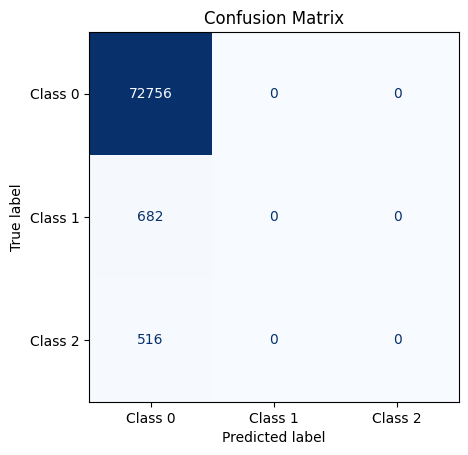

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize variables to collect predictions and ground truth labels
all_preds = []
all_labels = []

# Evaluate the model
with torch.no_grad():
    for batch in dataloader:
        # Assuming the batch consists of `inputs` and `labels`
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)

        # Forward pass
        outputs = custom_model(inputs)

        # Get predictions
        _, preds = torch.max(outputs, dim=1)

        # Collect predictions and labels
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1", "Class 2"])

# Plot confusion matrix
disp.plot(cmap=plt.cm.Blues, colorbar=False)
plt.title("Confusion Matrix")
plt.show()

## RNN classification

In [ ]:
import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

### Classifiers

In [ ]:
class RNNClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.2):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh',
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        _, hidden_state = self.rnn(x)
        last_hidden_state = hidden_state[-1]
        return self.classifier(last_hidden_state)

In [ ]:
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        _, (hidden_state, _) = self.lstm(x)
        last_hidden_state = hidden_state[-1]
        return self.classifier(last_hidden_state)

In [ ]:
class GRUClassifier(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, num_classes, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.classifier = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        _, hidden_state = self.gru(x)
        last_hidden_state = hidden_state[-1]
        return self.classifier(last_hidden_state)

### Simple RNN classification

In [ ]:
seq_len = 11
feature_dim = 135

video = '01'
x_buff = load(data_path + '/bbc_vec_buff/bbc_' + video + '_x_1.npy')
y_buff = load(data_path + '/bbc_vec_buff/bbc_' + video + '_y_1.npy')


x_tensor = torch.tensor(x_buff, dtype=torch.float32).reshape(-1, seq_len, feature_dim)
y_tensor = torch.tensor(y_buff, dtype=torch.long)

print(x_tensor.shape)
print(y_tensor.shape)

dataset = TensorDataset(x_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

print(len(dataset))
print(len(dataloader))

(73833, 1485)
(73833,)
torch.Size([73833, 11, 135])
torch.Size([73833])
73833
2308


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

input_size = feature_dim
hidden_size = 64
num_layers = 2
num_classes = 3

model = RNNClassifier(
    input_size=input_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    num_classes=num_classes,
).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")



RNNClassifier(
  (rnn): RNN(135, 64, num_layers=2, batch_first=True, dropout=0.2)
  (classifier): Linear(in_features=64, out_features=3, bias=True)
)
Trainable parameters: 21379
Epoch 1: Loss = 0.0659
Epoch 2: Loss = 0.0357
Epoch 3: Loss = 0.0258


In [ ]:
for epoch in range(3):
    model.train()
    running_loss = 0.0

    for x_batch, y_batch in dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(x_batch)
        loss = loss_fn(outputs, y_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x_batch.size(0)

    epoch_loss = running_loss / len(dataset)
    print(f"Epoch {epoch + 1}: Loss = {epoch_loss:.4f}")

In [ ]:
eval_dataloader = DataLoader(dataset, batch_size=32, shuffle=False)

model.eval()
all_preds = []
all_labels = []
correct_predictions = 0
total_samples = 0

with torch.no_grad():
    for x_batch, y_batch in eval_dataloader:
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(x_batch)
        _, preds = torch.max(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())
        correct_predictions += (preds == y_batch).sum().item()
        total_samples += y_batch.size(0)

Evaluation Accuracy: 0.9945
Confusion Matrix:
[[72489     8    12]
 [  364   525     2]
 [   19     0   414]]


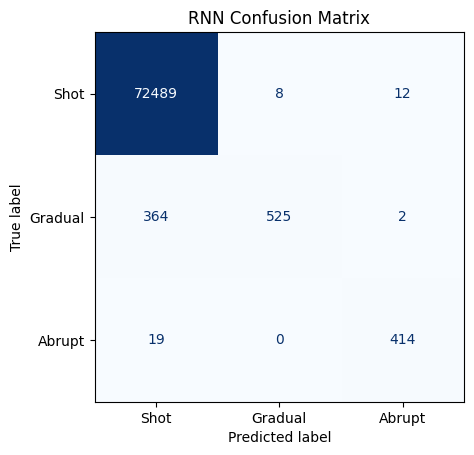

In [ ]:
accuracy = correct_predictions / total_samples
cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Shot", "Gradual", "Abrupt"])

print(f"Evaluation Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(cm)

disp.plot(cmap=plt.cm.Blues, colorbar=False)
plt.title("RNN Confusion Matrix")
plt.show()

### Aggregating classification models

In [ ]:
input_size = feature_dim
hidden_size = 64
num_layers = 2
num_classes = 3

model_specs = [
    (
        "RNN",
        RNNClassifier,
        {"input_size": input_size, "hidden_size": hidden_size, "num_layers": num_layers, "num_classes": num_classes},
    ),
    (
        "GRU",
        GRUClassifier,
        {"input_size": input_size, "hidden_size": hidden_size, "num_layers": num_layers, "num_classes": num_classes},
    ),
    (
        "LSTM",
        LSTMClassifier,
        {"input_size": input_size, "hidden_size": hidden_size, "num_layers": num_layers, "num_classes": num_classes},
    ),
]


def train_model(model, train_loader, device, loss_fn, optimizer, epochs=3):
    history = []
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x_batch.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        history.append(epoch_loss)
        print(f"Epoch {epoch + 1}: Loss = {epoch_loss:.4f}")

    return history


def evaluate_model(model, eval_loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for x_batch, y_batch in eval_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(x_batch)
            _, preds = torch.max(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
            correct_predictions += (preds == y_batch).sum().item()
            total_samples += y_batch.size(0)

    accuracy = correct_predictions / total_samples
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2])
    return accuracy, cm


In [ ]:
comparison_results = []

for model_name, model_class, model_kwargs in model_specs:
    comparison_model = model_class(**model_kwargs).to(device)
    comparison_loss_fn = nn.CrossEntropyLoss()
    comparison_optimizer = torch.optim.Adam(comparison_model.parameters(), lr=1e-3)

    print(f"\nTraining {model_name}")
    train_model(comparison_model, dataloader, device, comparison_loss_fn, comparison_optimizer, epochs=3)

    comparison_accuracy, comparison_cm = evaluate_model(comparison_model, eval_dataloader, device)
    comparison_results.append((model_name, comparison_accuracy, comparison_cm))

    print(f"{model_name} Accuracy: {comparison_accuracy:.4f}")
    print(comparison_cm)

In [ ]:
print("\nSummary")
for model_name, model_accuracy, _ in comparison_results:
    print(f"{model_name}: {model_accuracy:.4f}")


Summary
RNN: 0.9952
GRU: 0.9984
LSTM: 0.9967
